In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def identify_significant_up_and_down_DEGs(DEG_df):

    num_up_DEGs = DEG_df.loc[(DEG_df['significant'] == True) & (DEG_df['log2FoldChange'] > 0), :].shape[0]
    num_down_DEGs = DEG_df.loc[(DEG_df['significant'] == True) & (DEG_df['log2FoldChange'] < 0), :].shape[0]

    return([num_up_DEGs, num_down_DEGs])

In [3]:
cell_types = ["Adipocyte", "Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
              "Fibroblast", "Lymphoid", "LEC", "Mast", "Myeloid", "Neuronal", "Pericyte", "vSMC"]

In [4]:
sex_DEG_up_list = list()
sex_DEG_down_list = list()
age_DEG_up_list = list()
age_DEG_down_list = list()
disease_DEG_up_list = list()
disease_DEG_down_list = list()

for cell_type in cell_types:
    cell_type_age_df = pd.read_csv("pydeseq2_results/" + cell_type + "_age_group_old_vs_young_results.csv", index_col = 0)
    age_deg_up, age_deg_down  = identify_significant_up_and_down_DEGs(cell_type_age_df)
    age_DEG_up_list.append(age_deg_up)
    age_DEG_down_list.append(age_deg_down)
    
    cell_type_sex_df = pd.read_csv("pydeseq2_results/" + cell_type + "_sex_male_vs_female_results.csv", index_col = 0)
    sex_deg_up, sex_deg_down  = identify_significant_up_and_down_DEGs(cell_type_sex_df)
    sex_DEG_up_list.append(sex_deg_up)
    sex_DEG_down_list.append(sex_deg_down)

    cell_type_disease_df = pd.read_csv("pydeseq2_results/" + cell_type + "_disease_binary_Y_vs_N_results.csv", index_col = 0)
    disease_deg_up, disease_deg_down  = identify_significant_up_and_down_DEGs(cell_type_disease_df)
    disease_DEG_up_list.append(disease_deg_up)
    disease_DEG_down_list.append(disease_deg_down)

In [5]:
age_deg_down_df = pd.DataFrame({'cell_type': cell_types,
                              'DEG': age_DEG_down_list,
                               'direction': "down"})

age_deg_up_df = pd.DataFrame({'cell_type': cell_types,
                              'DEG': age_DEG_up_list,
                               'direction': "up"})

In [6]:
sex_deg_down_df = pd.DataFrame({'cell_type': cell_types,
                              'DEG': sex_DEG_down_list,
                               'direction': "down"})

sex_deg_up_df = pd.DataFrame({'cell_type': cell_types,
                              'DEG': sex_DEG_up_list,
                               'direction': "up"})

In [7]:
disease_deg_down_df = pd.DataFrame({'cell_type': cell_types,
                              'DEG': disease_DEG_down_list,
                               'direction': "down"})

disease_deg_up_df = pd.DataFrame({'cell_type': cell_types,
                              'DEG': disease_DEG_up_list,
                               'direction': "up"})

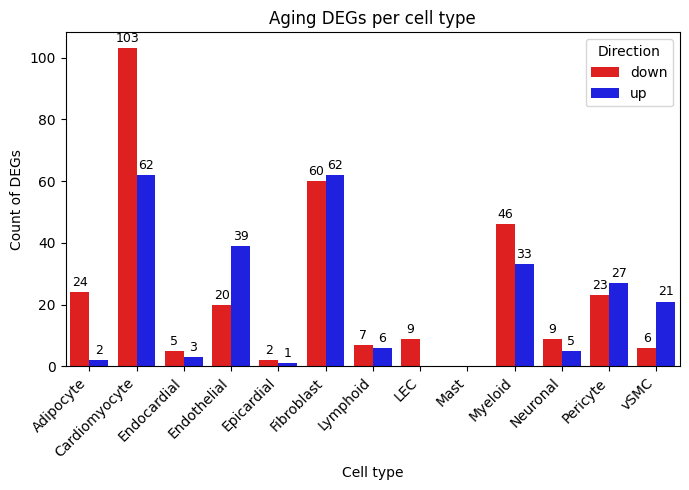

In [8]:
concat_age_df = pd.concat([age_deg_down_df, age_deg_up_df])
concat_age_df = concat_age_df.reset_index(drop=True)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=concat_age_df,
    x='cell_type',
    y='DEG',
    hue='direction',          # side-by-side bars
    palette={'up': 'blue', 'down': 'red'}
)

# Add counts on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label bars with positive height
        ax.text(
            x=p.get_x() + p.get_width()/2, 
            y=height + 1,  # small offset above bar
            s=int(height), 
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.ylabel("Count of DEGs")
plt.xlabel("Cell type")
plt.title("Aging DEGs per cell type")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

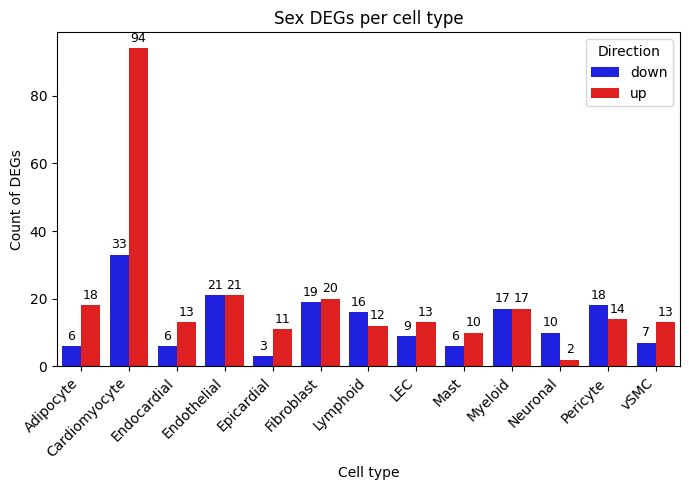

In [9]:
concat_sex_df = pd.concat([sex_deg_down_df, sex_deg_up_df])
concat_sex_df = concat_sex_df.reset_index(drop=True)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=concat_sex_df,
    x='cell_type',
    y='DEG',
    hue='direction',          # side-by-side bars
    palette={'up': 'red', 'down': 'blue'}
)

# Add counts on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label bars with positive height
        ax.text(
            x=p.get_x() + p.get_width()/2, 
            y=height + 1,  # small offset above bar
            s=int(height), 
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.ylabel("Count of DEGs")
plt.xlabel("Cell type")
plt.title("Sex DEGs per cell type")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

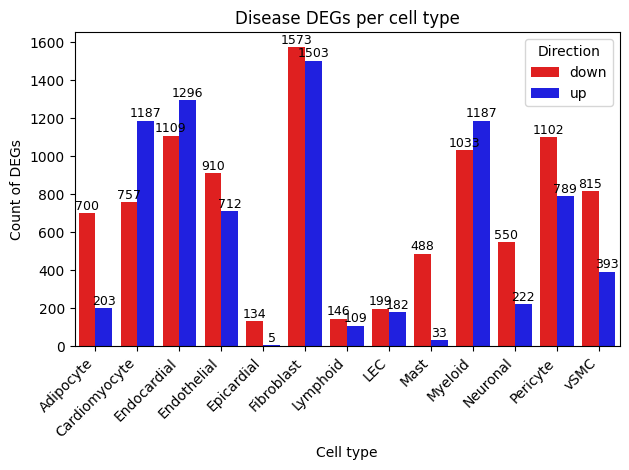

In [11]:
concat_disease_df = pd.concat([disease_deg_down_df, disease_deg_up_df])
concat_disease_df = concat_disease_df.reset_index(drop=True)

ax = sns.barplot(
    data=concat_disease_df,
    x='cell_type',
    y='DEG',
    hue='direction',          # side-by-side bars
    palette={'up': 'blue', 'down': 'red'}
)

# Add counts on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label bars with positive height
        ax.text(
            x=p.get_x() + p.get_width()/2, 
            y=height + 1,  # small offset above bar
            s=int(height), 
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.ylabel("Count of DEGs")
plt.xlabel("Cell type")
plt.title("Disease DEGs per cell type")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Direction')
plt.tight_layout()
plt.show()